# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">
<b>Comentário geral: </b> <a class="tocSkip"></a>
     
Parabéns pelo projeto, Javiera! 🎉 Seu trabalho está fenomenal:
    
- Apresentação com boas práticas de visualização e storytelling: Adorei tudo, desde os gráficos até o estilo da apresentação do PDF (adorei as cores!!! Confesso que vou até “copiar” algumas ideias para as minhas próprias apresentações 😄). Tudo muito profissional e bem feito!
- Bom uso dos comandos de bibliotecas em python: Todo o código está bem desenvolvido, com comentários em cada etapa. 

Espero que você tenha se divertido! 

Seu projeto está aprovado! 

Até a próxima! :) 
</div>

# Análise do mercado de restaurantes em Los Angeles

## Objetivo do projeto

O objetivo desta análise é avaliar as condições atuais do mercado de restaurantes em Los Angeles com o intuito de determinar a viabilidade de abrir uma cafeteria inovadora com garçons robóticos.

Busca-se identificar padrões relacionados ao tipo de estabelecimento, presença de redes, distribuição do número de assentos e localização geográfica, a fim de formular recomendações estratégicas para atrair investidores e garantir a sustentabilidade do negócio a longo prazo.

## Descrição dos dados

O conjunto de dados contém informações sobre estabelecimentos de alimentação em Los Angeles, incluindo:

* **object_name**: nome do estabelecimento
* **chain**: indica se pertence a uma rede (TRUE/FALSE)
* **object_type**: tipo de estabelecimento (restaurante, café, etc.)
* **address**: endereço do estabelecimento
* **number**: número de assentos

## Plano de análise

A análise será realizada nas seguintes etapas:

1. Preparação e limpeza dos dados
2. Análise exploratória do mercado
3. Identificação de padrões relevantes
4. Elaboração de conclusões e recomendações de negócio




#### Exploração inicial dos dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

df = pd.read_csv('/datasets/rest_data_us_upd.csv')
df.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


,id,number
count,9651.000000,9651.000000
mean,16611.000000,43.695161
std,2786.148058,47.622874
min,11786.000000,1.000000
25%,14198.500000,14.000000
50%,16611.000000,27.000000
75%,19023.500000,46.000000
max,21436.000000,229.000000


##  Exploração inicial dos dados

O conjunto de dados contém **9651 registros** e **6 colunas**. Não foram identificados valores ausentes na maioria das variáveis, com exceção da coluna **chain**, que apresenta **3 valores nulos**.

### Tipos de dados

* As colunas **id** e **number** estão no formato numérico (int64), o que é adequado.
* As demais colunas são do tipo texto (object).
* A coluna **chain** deveria ser do tipo booleano (TRUE/FALSE), portanto pode requerer tratamento.

### Valores ausentes

* A coluna **chain** possui 3 valores ausentes.
* Considerando o baixo número de registros afetados, estes podem ser removidos ou preenchidos posteriormente.

### Estatísticas descritivas

Em relação ao número de assentos (**number**):

* Média: aproximadamente **44 assentos**
* Mediana: **27 assentos**
* Valor máximo: **229 assentos**
* Valor mínimo: **1 assento**

Observa-se uma diferença significativa entre a média e a mediana, indicando uma possível **distribuição assimétrica**, com presença de estabelecimentos com grande número de assentos.

###  Observações iniciais

* A maioria dos estabelecimentos parece ser de pequeno a médio porte.
* Existem alguns poucos estabelecimentos com grande capacidade, que podem influenciar a média.
* Será importante analisar a distribuição dos assentos por tipo de estabelecimento e por presença de rede.


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Dados foram carregados corretamente.


</div>

In [4]:
# Vamos investigar os valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Registros com valores ausentes na coluna 'chain':")
print(df[df['chain'].isnull()])

Valores ausentes por coluna:
id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64

Registros com valores ausentes na coluna 'chain':
         id              object_name               address chain object_type  \
7408  19194  TAQUERIA LOS 3 CARNALES  5000 E WHITTIER BLVD   NaN  Restaurant   
7523  19309     JAMMIN JIMMY'S PIZZA   1641 FIRESTONE BLVD   NaN       Pizza   
8648  20434    THE LEXINGTON THEATER          129 E 3RD ST   NaN  Restaurant   

      number  
7408      14  
7523       1  
8648      35  


In [5]:
# Remover registros com valores ausentes na coluna 'chain'
df_limpo = df.dropna(subset=['chain'])
print(f"Dataset original: {len(df)} registros")
print(f"Dataset após remoção: {len(df_limpo)} registros")
print(f"Registros removidos: {len(df) - len(df_limpo)}")


Dataset original: 9651 registros
Dataset após remoção: 9648 registros
Registros removidos: 3


In [6]:
# Verificar se há registros duplicados
print("Verificação de duplicados:")
print(f"Total de registros: {len(df_limpo)}")
print(f"Registros únicos: {len(df_limpo.drop_duplicates())}")
print(f"Registros duplicados: {len(df_limpo) - len(df_limpo.drop_duplicates())}")

Verificação de duplicados:
Total de registros: 9648
Registros únicos: 9648
Registros duplicados: 0


### Análises de dados

In [7]:
# Verificar os tipos de estabelecimentos únicos
print("Tipos de estabelecimentos no dataset:")
print(df_limpo['object_type'].unique())
print("\n" + "="*50 + "\n")

# Sua análise atual
import matplotlib.pyplot as plt
import seaborn as sns
# contagem por tipo
type_counts = df_limpo['object_type'].value_counts()
# proporções
type_proportions = df_limpo['object_type'].value_counts(normalize=True) * 100
print(type_proportions)

Tipos de estabelecimentos no dataset:
['Cafe' 'Restaurant' 'Fast Food' 'Bakery' 'Bar' 'Pizza']


Restaurant    75.176202
Fast Food     11.048922
Cafe           4.508706
Pizza          3.306385
Bar            3.026534
Bakery         2.933250
Name: object_type, dtype: float64


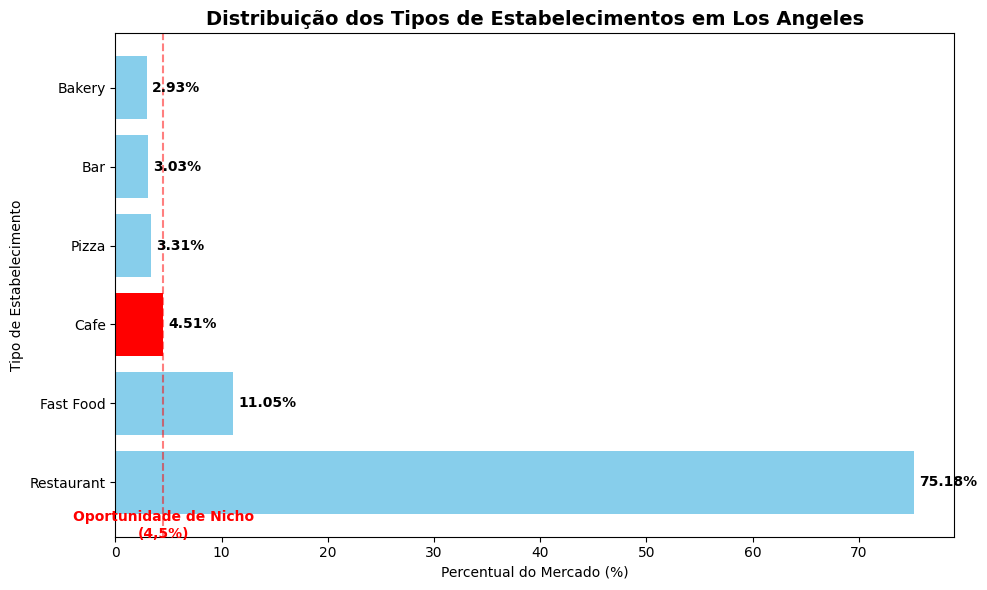

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

tipos = ['Restaurant', 'Fast Food', 'Cafe', 'Pizza', 'Bar', 'Bakery']
percentuais = [75.18, 11.05, 4.51, 3.31, 3.03, 2.93]

# Criar cores - destacar Cafe em vermelho
cores = ['red' if tipo == 'Cafe' else 'skyblue' for tipo in tipos]

plt.figure(figsize=(10, 6))
bars = plt.barh(tipos, percentuais, color=cores)

# Adicionar valores nas barras
for i, v in enumerate(percentuais):
    plt.text(v + 0.5, i, f'{v}%', va='center', fontweight='bold')

plt.title('Distribuição dos Tipos de Estabelecimentos em Los Angeles', 
          fontsize=14, fontweight='bold')
plt.xlabel('Percentual do Mercado (%)')
plt.ylabel('Tipo de Estabelecimento')

# Adicionar linha de destaque para cafés
plt.axvline(x=4.51, color='red', linestyle='--', alpha=0.5)
plt.text(4.51, -0.7, 'Oportunidade de Nicho\n(4,5%)', 
         ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

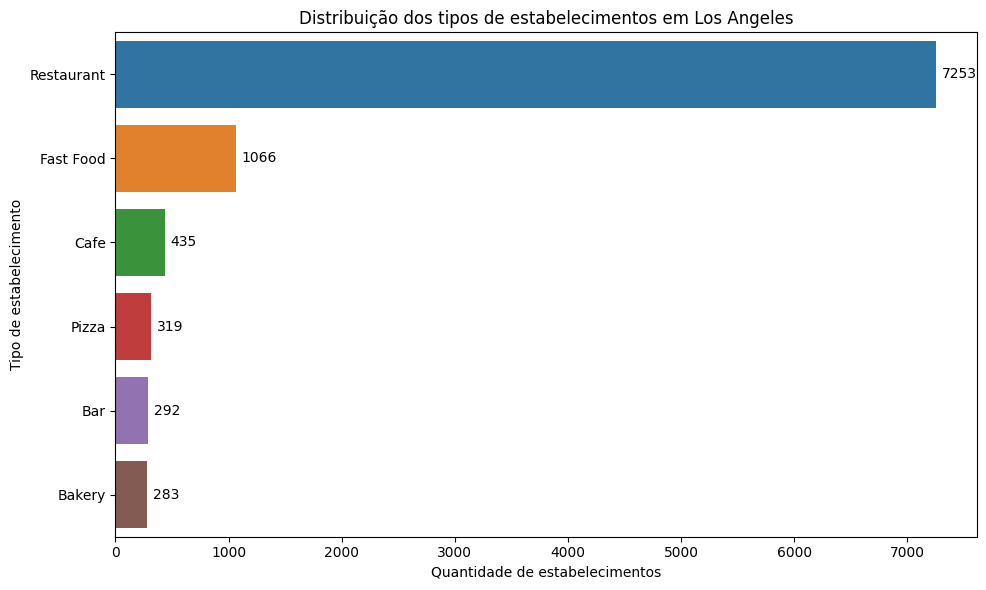

In [12]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=type_counts.values,
    y=type_counts.index
)

# Adicionar valores nas barras
for i, v in enumerate(type_counts.values):
    ax.text(v + 50, i, str(v), va='center')

# Criar cores diferentes para destacar os cafés
colors = ['red' if x == 'Cafe' else 'skyblue' for x in type_counts.index]

plt.title('Distribuição dos tipos de estabelecimentos em Los Angeles')
plt.xlabel('Quantidade de estabelecimentos')
plt.ylabel('Tipo de estabelecimento')
plt.tight_layout()
plt.show()

## Proporção dos tipos de estabelecimentos

A análise da variável **object_type** mostra a distribuição dos diferentes tipos de estabelecimentos no mercado de Los Angeles.

Observa-se que alguns tipos de estabelecimentos predominam no mercado, indicando maior demanda ou maior consolidação nesses segmentos. Compreender essa distribuição é importante para identificar oportunidades de negócio e avaliar o nível de concorrência para a abertura de uma nova cafeteria.

### Conclusão da análise

A análise dos dados revela que o mercado de estabelecimentos alimentícios em Los Angeles é dominado por **restaurantes tradicionais**, que representam aproximadamente **75,18%** do total. O segmento de **fast food** ocupa a segunda posição, com cerca de **11,05%**, enquanto os **cafés** correspondem a aproximadamente **4,51%** do mercado.

Esses resultados sugerem que o segmento de restaurantes tradicionais apresenta alta competitividade, enquanto cafeterias representam um nicho relativamente menos explorado.

Do ponto de vista estratégico:

* A baixa participação de cafeterias pode indicar uma **oportunidade de entrada em um mercado menos saturado**;
* Uma proposta inovadora, como uma cafeteria com **garçons robóticos**, pode gerar **diferenciação competitiva**;
* O conceito pode atrair consumidores em busca de uma experiência diferenciada, especialmente em áreas de alta circulação.

Portanto, os dados iniciais sugerem que a abertura de uma cafeteria em Los Angeles pode ser uma alternativa promissora, desde que a localização, o tamanho e o posicionamento estratégico sejam definidos com base em análises adicionais.

### Próximos passos da análise

Para validar essa oportunidade com maior precisão, as próximas etapas incluirão:

* **Distribuição geográfica dos estabelecimentos**, para identificar áreas com maior ou menor concentração de concorrentes;
* **Análise da presença de redes e estabelecimentos independentes**, para entender o nível de competitividade do mercado;
* **Distribuição do número de assentos**, para definir o porte ideal do novo negócio;
* **Identificação de localizações estratégicas**, considerando ruas e regiões com potencial de demanda.

Essas análises permitirão formular recomendações mais precisas sobre o melhor formato, tamanho e localização para a abertura da cafeteria.




In [13]:
# Contar estabelecimentos de rede vs não-rede
chain_counts = df_limpo['chain'].value_counts()
print("Contagem absoluta:")
print(chain_counts)

# Calcular proporções em percentual
chain_proportions = df_limpo['chain'].value_counts(normalize=True) * 100
print("\nProporções em percentual:")
print(chain_proportions)

Contagem absoluta:
False    5972
True     3676
Name: chain, dtype: int64

Proporções em percentual:
False    61.898839
True     38.101161
Name: chain, dtype: float64


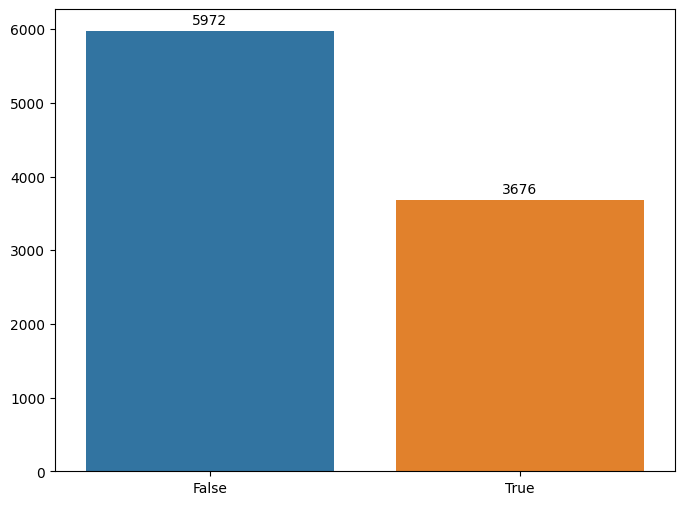

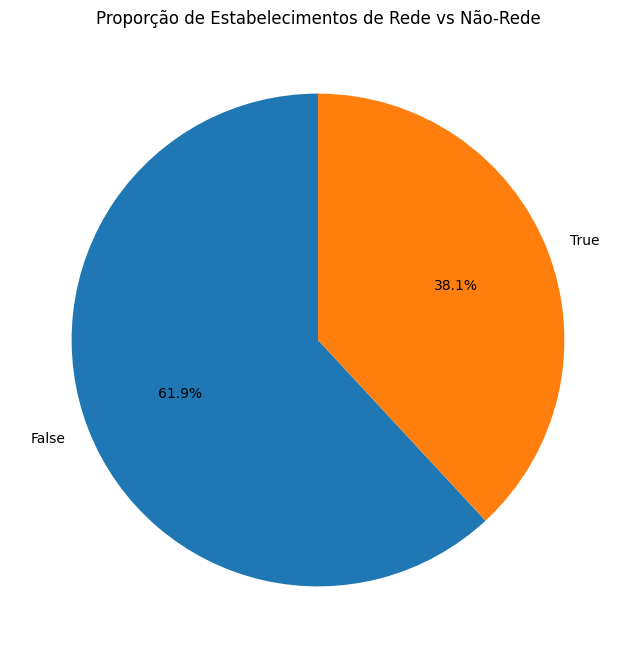

In [14]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=chain_counts.index, y=chain_counts.values)

# Adicionar valores nas barras
for i, v in enumerate(chain_counts.values):
    ax.text(i, v + 50, str(v), ha='center', va='bottom')

plt.figure(figsize=(8, 8))
plt.pie(chain_counts.values, labels=chain_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Estabelecimentos de Rede vs Não-Rede')
plt.show()

### Interpretação dos resultados

Os dados mostram que:

* **61,9%** dos estabelecimentos são **independentes**, ou seja, não pertencem a redes;
* **38,1%** correspondem a **estabelecimentos de rede**.

Esses resultados indicam que o mercado de Los Angeles é predominantemente composto por negócios independentes. No entanto, a participação significativa de redes sugere que esse modelo também possui forte presença e competitividade no setor alimentício.

### Implicações para o negócio

Os resultados obtidos trazem insights importantes para a proposta de abrir uma **cafeteria com garçons robóticos** em Los Angeles.

A predominância de **estabelecimentos independentes (61,9%)** sugere que o mercado permite a entrada de novos negócios com conceitos diferenciados. Isso pode representar uma oportunidade para introduzir uma cafeteria inovadora, focada em experiência tecnológica e atendimento automatizado.

Por outro lado, a presença significativa de **redes (38,1%)** demonstra que modelos escaláveis e padronizados também possuem forte aceitação no mercado. Isso pode representar:

* **Uma ameaça**, devido à concorrência com marcas consolidadas, maior capacidade de investimento e reconhecimento de marca;
* **Uma oportunidade**, caso o negócio consiga se diferenciar e, no futuro, adotar um modelo replicável e expansível.

Nesse cenário, a cafeteria robótica pode iniciar como um **negócio independente inovador**, validando sua aceitação no mercado e construindo uma base de clientes. Caso o conceito seja bem-sucedido, existe potencial para expansão e transformação em uma **rede**, aproveitando a padronização proporcionada pela automação.

Além disso, o uso de garçons robóticos pode gerar vantagens estratégicas, como:

* redução de custos operacionais no longo prazo;
* experiência diferenciada para atrair clientes;
* maior padronização no atendimento;
* potencial de marketing e viralização nas redes sociais.

Portanto, os dados sugerem que o mercado apresenta espaço tanto para inovação quanto para expansão, tornando a proposta atrativa para investidores.

In [19]:
chain_type = df[df['chain'] == True]['object_type'].value_counts(normalize=True) * 100
print(chain_type)

Restaurant    62.350381
Fast Food     16.458107
Bakery         7.698585
Cafe           7.236126
Pizza          4.162133
Bar            2.094668
Name: object_type, dtype: float64


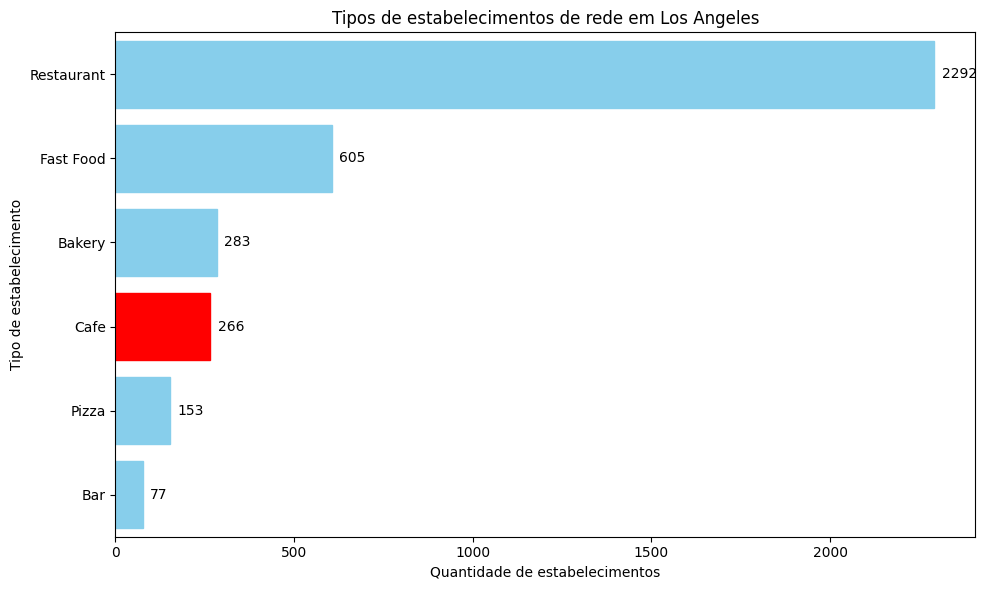

In [15]:
# Preparar os dados
chain_establishments = df_limpo[df_limpo['chain'] == True]
type_counts_chain = chain_establishments['object_type'].value_counts()

# Criar o gráfico
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=type_counts_chain.values,
    y=type_counts_chain.index,
    palette='viridis'  # ou use cores personalizadas como nos seus outros gráficos
)

# Adicionar valores nas barras (seguindo seu padrão)
for i, v in enumerate(type_counts_chain.values):
    ax.text(v + 20, i, str(v), va='center')

# Destacar cafés com cor diferente (como você fez no primeiro gráfico)
colors = ['red' if x == 'Cafe' else 'skyblue' for x in type_counts_chain.index]
for i, bar in enumerate(ax.patches):
    bar.set_color(colors[i])

plt.title('Tipos de estabelecimentos de rede em Los Angeles')
plt.xlabel('Quantidade de estabelecimentos')
plt.ylabel('Tipo de estabelecimento')
plt.tight_layout()
plt.show()

### Conclusão

Para entender quais tipos de estabelecimentos são mais típicos para redes, foi feita uma comparação entre a distribuição geral do mercado e a distribuição dos estabelecimentos que pertencem a redes.

#### Distribuição geral vs. estabelecimentos de rede

* **Restaurantes:** 75,18% → 62,35% (**redução**)
* **Fast Food:** 11,05% → 16,46% (**aumento de aproximadamente 49%**)
* **Cafés:** 4,51% → 7,24% (**aumento de aproximadamente 60%**)

###  Interpretação

Os dados mostram que **cafés** e **fast food** possuem maior representatividade entre os estabelecimentos de rede quando comparados ao mercado geral.

Isso sugere que esses modelos de negócio apresentam características que favorecem a expansão, como:

* operações mais padronizadas;
* cardápios mais simples;
* processos mais fáceis de replicar;
* menor necessidade de personalização no atendimento.

Por outro lado, os **restaurantes tradicionais** reduzem sua participação relativa entre as redes, o que pode indicar maior dificuldade de padronização devido a:

* cardápios mais complexos;
* maior necessidade de atendimento personalizado;
* operações mais variadas.

### Implicações para a cafeteria robótica

Esses resultados apoiam a viabilidade de desenvolver uma **rede de cafeterias**, especialmente quando combinada com tecnologia.

O uso de garçons robóticos pode oferecer vantagens estratégicas para facilitar a expansão, como:

* maior padronização no atendimento;
* redução de custos operacionais;
* experiência inovadora e atrativa para os clientes;
* replicação mais simples do modelo em novas unidades.

Portanto, os dados sugerem que uma cafeteria robótica possui potencial não apenas para operar como negócio independente, mas também para se tornar uma **rede escalável** no futuro.




In [16]:
# 1. Filtrar apenas estabelecimentos de rede
chain_rest = df_limpo[df_limpo['chain'] == True]

# 2. Agrupar por nome da rede (object_name)
chain_grouped = chain_rest.groupby('object_name').agg({
    'id': 'count',           # conta quantos estabelecimentos cada rede tem
    'number': 'mean'         # média de assentos por estabelecimento da rede
}).reset_index()

# 3. Renomear colunas para facilitar interpretação
chain_grouped.columns = ['chain_name', 'establishments_count', 'avg_seats']

# 4. Ordenar por número de estabelecimentos (decrescente)
chain_grouped = chain_grouped.sort_values('establishments_count', ascending=False)

print("Top 10 redes com mais estabelecimentos:")
print(chain_grouped.head(10))

Top 10 redes com mais estabelecimentos:
                      chain_name  establishments_count  avg_seats
2459  THE COFFEE BEAN & TEA LEAF                    47  26.723404
2226                      SUBWAY                    31  16.419355
519               DOMINO'S PIZZA                    15  12.333333
2608                  WABA GRILL                    14  42.857143
1089      KENTUCKY FRIED CHICKEN                    14  33.357143
1433                  MCDONALD'S                    13  96.846154
2544                     TRIMANA                    13  43.461538
2103                   STARBUCKS                    12  18.000000
1735           PAPA JOHN'S PIZZA                    12  14.500000
2667                  YOGURTLAND                    12  16.416667


In [17]:
# Estatísticas descritivas
print("Estatísticas das redes:")
print(f"Média de estabelecimentos por rede: {chain_grouped['establishments_count'].mean():.1f}")
print(f"Mediana de estabelecimentos por rede: {chain_grouped['establishments_count'].median():.1f}")
print(f"Média de assentos por estabelecimento: {chain_grouped['avg_seats'].mean():.1f}")
print(f"Mediana de assentos por estabelecimento: {chain_grouped['avg_seats'].median():.1f}")

Estatísticas das redes:
Média de estabelecimentos por rede: 1.3
Mediana de estabelecimentos por rede: 1.0
Média de assentos por estabelecimento: 41.4
Mediana de assentos por estabelecimento: 25.5


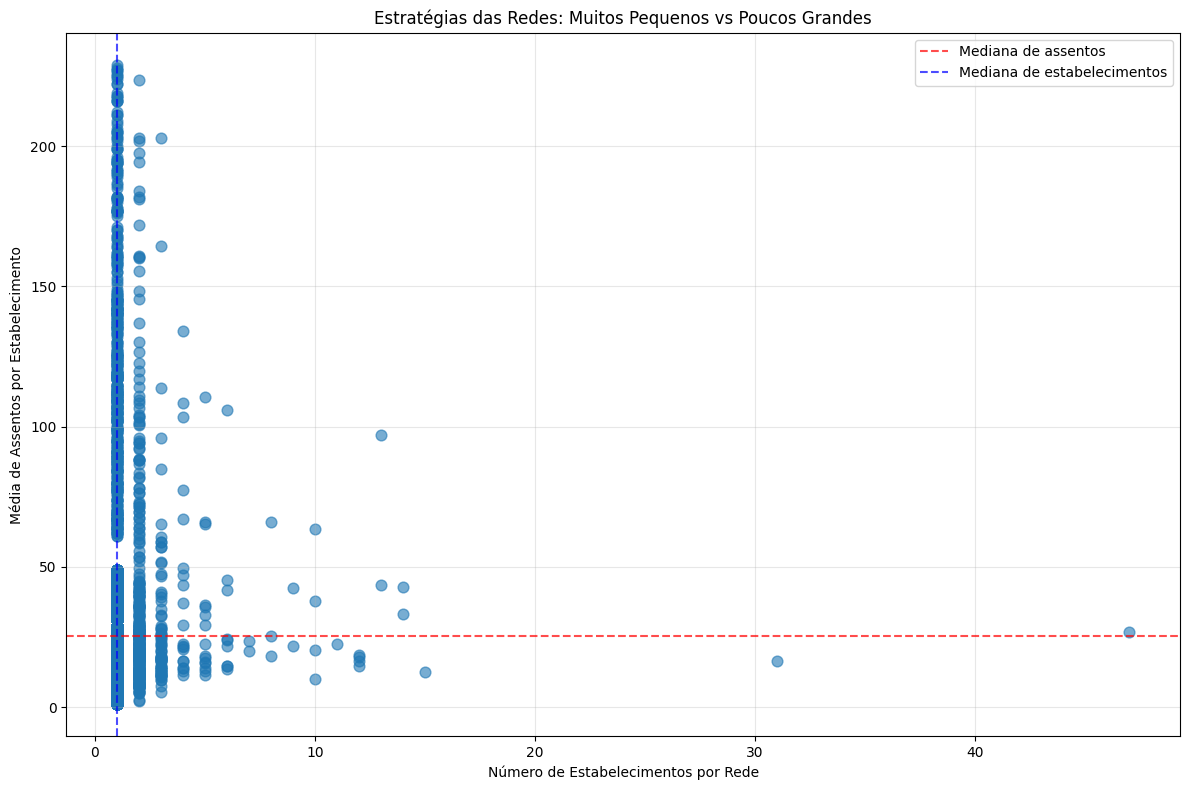

In [18]:

# Criar gráfico de dispersão para ver a relação
plt.figure(figsize=(12, 8))
plt.scatter(chain_grouped['establishments_count'], 
           chain_grouped['avg_seats'], 
           alpha=0.6, s=60)

plt.xlabel('Número de Estabelecimentos por Rede')
plt.ylabel('Média de Assentos por Estabelecimento')
plt.title('Estratégias das Redes: Muitos Pequenos vs Poucos Grandes')
plt.grid(True, alpha=0.3)

# Adicionar linha de referência
plt.axhline(y=chain_grouped['avg_seats'].median(), color='red', linestyle='--', alpha=0.7, label='Mediana de assentos')
plt.axvline(x=chain_grouped['establishments_count'].median(), color='blue', linestyle='--', alpha=0.7, label='Mediana de estabelecimentos')

plt.legend()
plt.tight_layout()
plt.show()


### Interpretação dos resultados

A análise do gráfico de dispersão revela que as redes em Los Angeles parecem adotar **duas estratégias principais de negócio**.

#### 1. Redes com muitos estabelecimentos e tamanho padronizado

No lado direito do gráfico, observa-se que as redes com maior número de unidades tendem a manter uma média de assentos próxima à mediana do mercado (**25,5 assentos**).

Isso sugere uma estratégia focada em:

* **padronização operacional**;
* **facilidade de replicação**;
* **menor custo por unidade**;
* **expansão rápida para diferentes localizações**.

Esse padrão pode ser observado em redes como:

* **The Coffee Bean & Tea Leaf**, com **47 unidades** e média de **26,7 assentos**;
* **Subway**, com **31 unidades** e média de **16,4 assentos**.

Esse modelo é comum em cafeterias, fast food e outros formatos de alta rotatividade.

#### 2. Redes com poucos estabelecimentos e tamanhos variados

No lado esquerdo do gráfico, encontram-se redes com menor número de unidades, mas com grande variação no número de assentos.

Nesse grupo:

* algumas unidades mantêm porte médio;
* outras possuem grande capacidade, como o **McDonald's**, com média de **96,8 assentos** por unidade.

Isso sugere uma estratégia mais focada em:

* maior capacidade de atendimento por unidade;
* experiência mais completa no local;
* maior investimento por estabelecimento.

### Implicações para a cafeteria robótica

Para a proposta de uma cafeteria com garçons robóticos, os dados sugerem que a estratégia mais viável inicialmente seria seguir o primeiro modelo:

* unidades pequenas ou médias;
* operação padronizada;
* alta eficiência operacional;
* possibilidade de expansão futura.

Após validar o modelo de negócio, a empresa poderia considerar expansão em formato de rede, aproveitando a automação para manter consistência no atendimento e na operação.



In [20]:
# Calcular média de assentos por tipo de restaurante
avg_seats_by_type = df_limpo.groupby('object_type')['number'].agg(['mean', 'median', 'count']).round(1)
avg_seats_by_type.columns = ['média_assentos', 'mediana_assentos', 'quantidade_estabelecimentos']
avg_seats_by_type = avg_seats_by_type.sort_values('média_assentos', ascending=False)
print(avg_seats_by_type)

             média_assentos  mediana_assentos  quantidade_estabelecimentos
object_type                                                               
Restaurant             48.0              29.0                         7253
Bar                    44.8              28.5                          292
Fast Food              31.8              21.0                         1066
Pizza                  28.5              19.0                          319
Cafe                   25.0              21.0                          435
Bakery                 21.8              18.0                          283


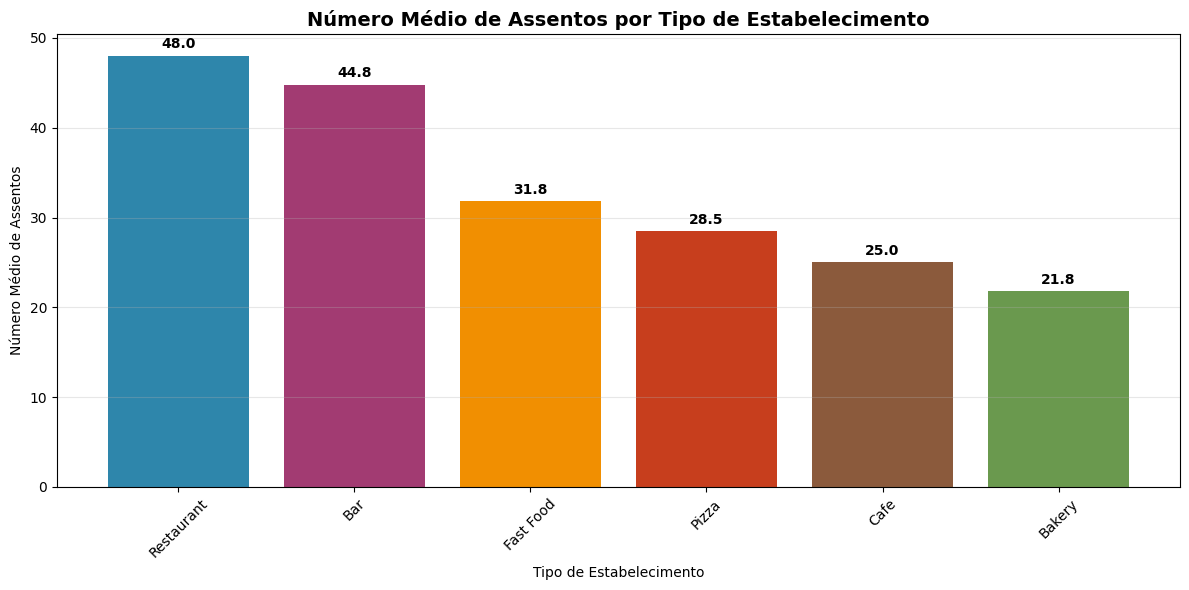

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(avg_seats_by_type.index, avg_seats_by_type['média_assentos'], 
               color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#8B5A3C', '#6A994E'])

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title('Número Médio de Assentos por Tipo de Estabelecimento', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número Médio de Assentos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretação dos resultados

A análise do gráfico mostra diferenças importantes entre os tipos de estabelecimentos em Los Angeles, tanto em quantidade quanto em capacidade média de assentos.

Os **restaurantes tradicionais** dominam o mercado, com aproximadamente **7.253 estabelecimentos**, representando cerca de **75%** do total. Além disso, apresentam a maior média de assentos (**48 lugares**), indicando operações maiores e possivelmente voltadas para permanência mais longa dos clientes.

Por outro lado, as **cafeterias** representam um nicho menor, com cerca de **435 unidades**, o equivalente a aproximadamente **4,5%** do mercado, e possuem uma média de **25 assentos** por estabelecimento.

Esses resultados sugerem que:

* o segmento de restaurantes apresenta **alta competitividade**, devido ao grande número de concorrentes;
* o segmento de cafeterias possui **menor saturação**, podendo representar uma oportunidade de entrada em um nicho menos explorado;
* o porte médio das cafeterias pode ser mais adequado para implementar um modelo inovador e operacionalmente eficiente.

### Implicações para a cafeteria com garçons robóticos

Do ponto de vista estratégico, esses dados fortalecem a proposta de uma cafeteria com garçons robóticos por dois motivos principais:

* **Menor concorrência direta:** com menos cafeterias no mercado em comparação aos restaurantes tradicionais, a competição no segmento tende a ser menor;
* **Tamanho ideal para inovação:** a média de **25 assentos** sugere um porte intermediário, que pode ser suficiente para gerar impacto na experiência do cliente e, ao mesmo tempo, manter a operação viável para testes com tecnologia robótica.

Portanto, os dados indicam que uma cafeteria automatizada pode combinar **diferenciação**, **eficiência operacional** e **potencial de escalabilidade**.




In [21]:

# Extrair nome da rua removendo o número do endereço
df['street_name'] = df['address'].str.replace(r'^\d+\s', '', regex=True)
# Depois filtre os valores nulos se necessário
df_limpo = df.dropna(subset=['chain']).copy()

# Verificar se a coluna foi criada corretamente
print("Primeiros 5 exemplos:")
print(df_limpo[['address', 'street_name']].head())

# Ver as ruas com mais estabelecimentos
print("\nTop 10 ruas com mais estabelecimentos:")
street_counts = df_limpo['street_name'].value_counts().head(10)
print(street_counts)

Primeiros 5 exemplos:
                   address         street_name
0   3708 N EAGLE ROCK BLVD   N EAGLE ROCK BLVD
1        100 WORLD WAY 120       WORLD WAY 120
2  6801 HOLLYWOOD BLVD 253  HOLLYWOOD BLVD 253
3       1814 W SUNSET BLVD       W SUNSET BLVD
4       2100 ECHO PARK AVE       ECHO PARK AVE

Top 10 ruas com mais estabelecimentos:
W SUNSET BLVD        296
W PICO BLVD          288
HOLLYWOOD BLVD       167
WILSHIRE BLVD        161
S VERMONT AVE        148
SANTA MONICA BLVD    146
W 3RD ST             145
BEVERLY BLVD         135
S FIGUEROA ST        134
S WESTERN AVE        128
Name: street_name, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
    
O processamento do nome de ruas está correto. Bom uso de regex!

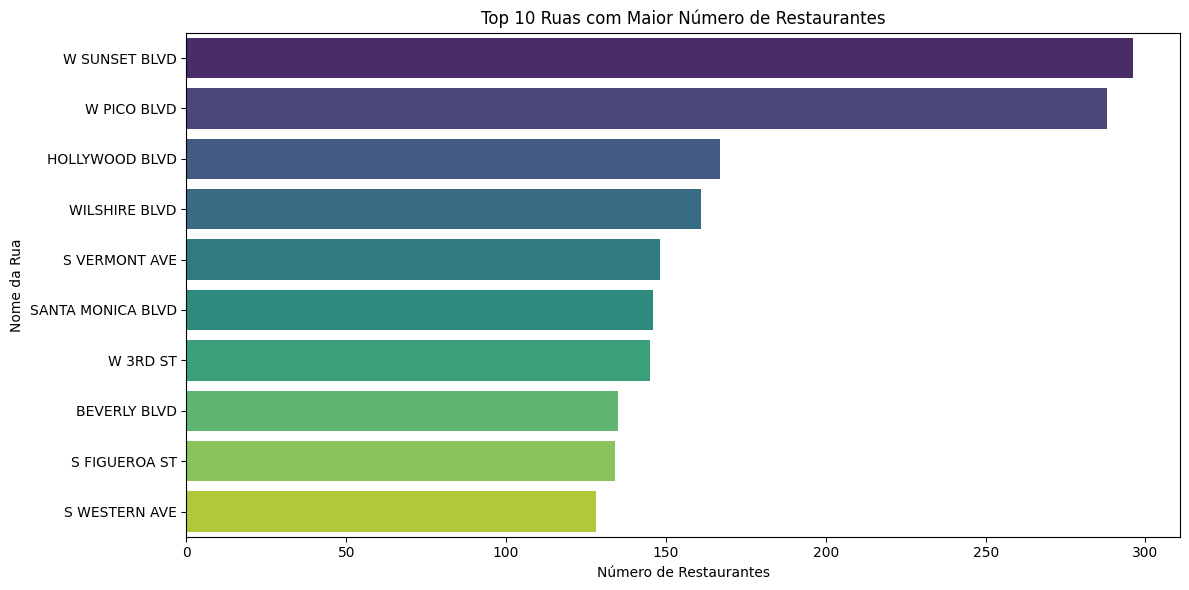

In [22]:
# Criar o gráfico das top 10 ruas
plt.figure(figsize=(12, 6))
sns.barplot(x=street_counts.values, y=street_counts.index, palette='viridis')
plt.title('Top 10 Ruas com Maior Número de Restaurantes')
plt.xlabel('Número de Restaurantes')
plt.ylabel('Nome da Rua')
plt.tight_layout()
plt.show()

### Interpretação dos resultados

A análise da distribuição geográfica dos estabelecimentos mostra que algumas ruas concentram um grande número de restaurantes e cafeterias em Los Angeles.

As ruas com maior concentração são **W Sunset Blvd** (**296 estabelecimentos**) e **W Pico Blvd** (**288 estabelecimentos**), seguidas por **Hollywood Blvd** (**167**) e **Wilshire Blvd** (**161**).

Esses resultados indicam que essas regiões possuem alta atividade comercial e grande fluxo de pessoas, tornando-se áreas potencialmente atrativas para novos negócios. No entanto, a alta concentração de estabelecimentos também sugere **maior concorrência**.

Para a proposta de uma cafeteria com garçons robóticos, essas localizações podem oferecer maior visibilidade e demanda, mas será necessário avaliar cuidadosamente o equilíbrio entre **oportunidade de mercado** e **nível de competitividade**.

In [23]:
# O número de ruas que têm apenas um restaurante.
single_restaurant_streets = (df['street_name'].value_counts() == 1).sum()

print('Número de ruas com apenas um restaurante:', single_restaurant_streets)
total_streets = df['street_name'].nunique()
proportion = (single_restaurant_streets / total_streets) * 100
print(f'Isso representa {proportion:.1f}% do total de ruas')

Número de ruas com apenas um restaurante: 2450
Isso representa 79.6% do total de ruas


In [24]:
# Primeiro, vamos ver quantos estabelecimentos cada rua tem por tipo
street_type_counts = df_limpo.groupby(['street_name', 'object_type']).size().unstack(fill_value=0)

# Agora vamos identificar ruas que têm APENAS cafeterias
# (ou seja, têm cafeterias mas zero de todos os outros tipos)
only_cafes_streets = street_type_counts[
    (street_type_counts['Cafe'] > 0) &  # tem pelo menos 1 café
    (street_type_counts['Restaurant'] == 0) &  # zero restaurantes
    (street_type_counts['Fast Food'] == 0) &   # zero fast food
    (street_type_counts['Pizza'] == 0) &       # zero pizzarias
    (street_type_counts['Bar'] == 0) &         # zero bares
    (street_type_counts['Bakery'] == 0)        # zero padarias
]

print(f"Número de ruas com APENAS cafeterias: {len(only_cafes_streets)}")

Número de ruas com APENAS cafeterias: 131


In [25]:
# filtrar cafeterias
cafes = df[df['object_type'] == 'Cafe']

# contar ruas com apenas uma cafeteria
single_cafe_streets = (cafes['street_name'].value_counts() == 1).sum()

print('Número de ruas com apenas uma cafeteria:', single_cafe_streets)

Número de ruas com apenas uma cafeteria: 222


In [26]:
# Para as ruas com muitos restaurantes, olhe para a distribuição de número de assentos. Quais tendências você consegue notar?

# Pegar as top 10 ruas com mais estabelecimentos
top_streets = df_limpo['street_name'].value_counts().head(10)
print("Top 10 ruas:")
print(top_streets)

# Filtrar dados apenas das ruas com muitos restaurantes
busy_streets_data = df_limpo[df_limpo['street_name'].isin(top_streets.index)]

# Analisar distribuição de assentos
seats_distribution = busy_streets_data['number'].describe()
print("\nDistribuição de assentos nas ruas movimentadas:")
print(seats_distribution)

Top 10 ruas:
W SUNSET BLVD        296
W PICO BLVD          288
HOLLYWOOD BLVD       167
WILSHIRE BLVD        161
S VERMONT AVE        148
SANTA MONICA BLVD    146
W 3RD ST             145
BEVERLY BLVD         135
S FIGUEROA ST        134
S WESTERN AVE        128
Name: street_name, dtype: int64

Distribuição de assentos nas ruas movimentadas:
count    1748.000000
mean       46.952517
std        47.919599
min         1.000000
25%        16.000000
50%        31.000000
75%        48.000000
max       229.000000
Name: number, dtype: float64


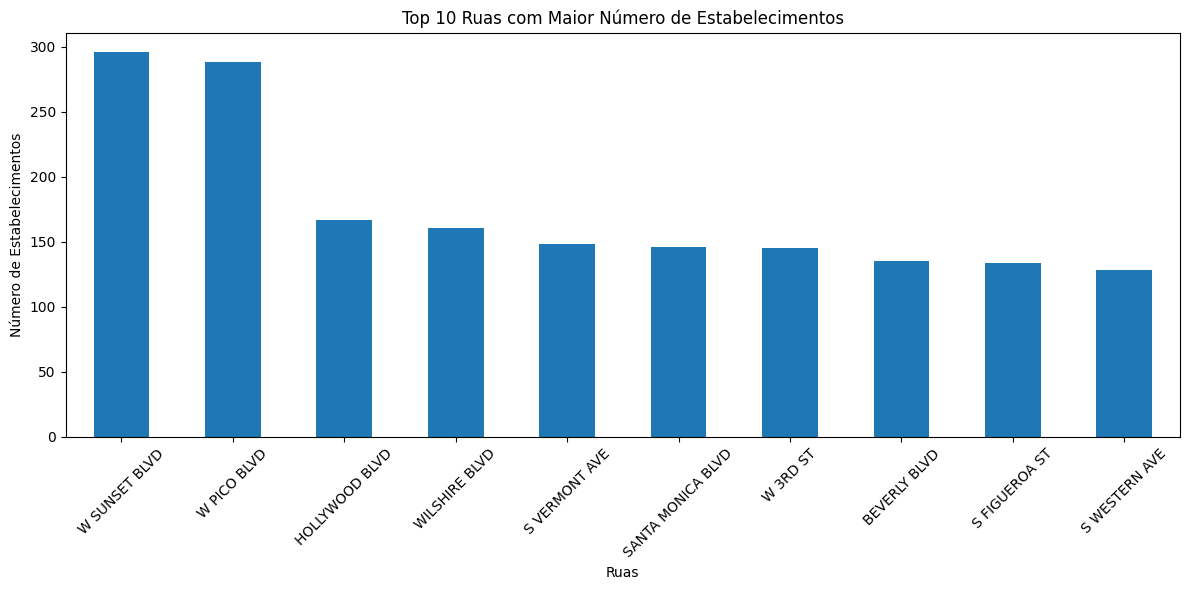

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
top_streets.plot(kind='bar')
plt.title('Top 10 Ruas com Maior Número de Estabelecimentos')
plt.xlabel('Ruas')
plt.ylabel('Número de Estabelecimentos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequência')

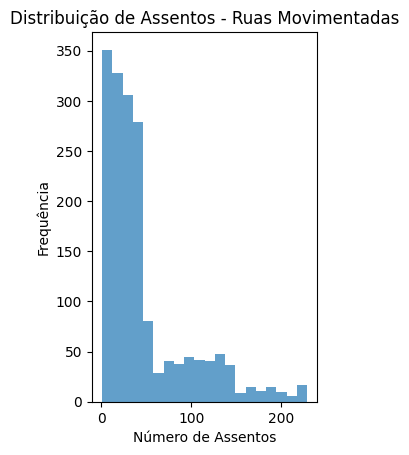

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


# Subplot 1: Ruas movimentadas
plt.subplot(1, 2, 1)
plt.hist(busy_streets_data['number'], bins=20, alpha=0.7)
plt.title('Distribuição de Assentos - Ruas Movimentadas')
plt.xlabel('Número de Assentos')
plt.ylabel('Frequência')


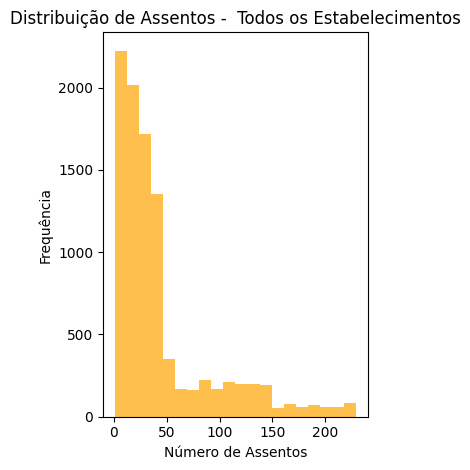

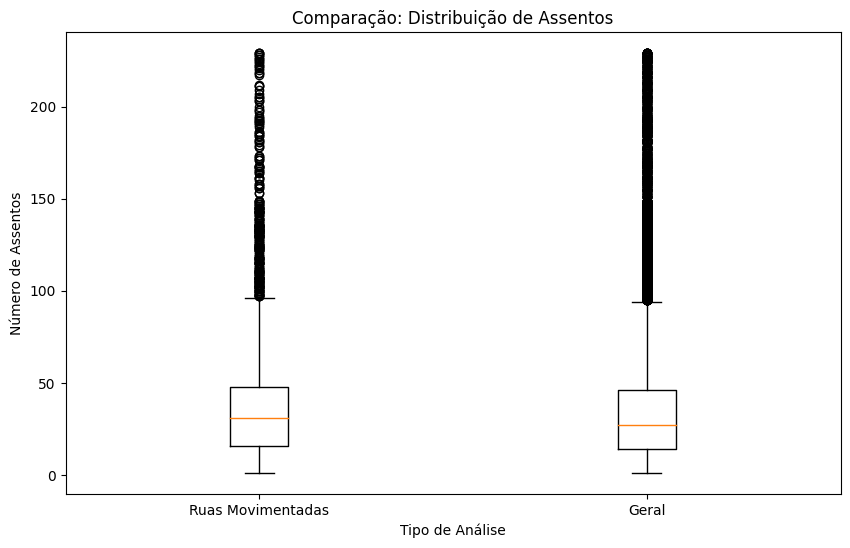

In [29]:
# Subplot 2: Dataset completo
plt.subplot(1, 2, 2)
plt.hist(df_limpo['number'], bins=20, alpha=0.7, color='orange')
plt.title('Distribuição de Assentos -  Todos os Estabelecimentos')
plt.xlabel('Número de Assentos')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

#Boxplot - Comparacao Visual
plt.figure(figsize=(10, 6))
data_comparison = [busy_streets_data['number'], df_limpo['number']]
plt.boxplot(data_comparison, labels=['Ruas Movimentadas', 'Geral'])
plt.title('Comparação: Distribuição de Assentos')
plt.xlabel('Tipo de Análise')
plt.ylabel('Número de Assentos')
plt.show()

### Interpretação dos resultados

A análise das **10 ruas com maior concentração de estabelecimentos** mostra que determinadas regiões de Los Angeles apresentam alta atividade comercial e grande fluxo de consumidores.

As ruas com maior número de estabelecimentos são:

* **W Sunset Blvd** com **296 estabelecimentos**;
* **W Pico Blvd** com **288 estabelecimentos**;
* **Hollywood Blvd** com **167 estabelecimentos**.

Essas localizações podem representar áreas estratégicas para a abertura de um novo negócio devido à maior circulação de pessoas e à alta demanda potencial. No entanto, a elevada concentração de estabelecimentos também indica **forte concorrência**.

Em relação à distribuição do número de assentos nessas ruas movimentadas:

* a média é de aproximadamente **47 assentos**;
* a mediana é de **31 assentos**;
* 75% dos estabelecimentos possuem até **48 assentos**;
* existem outliers com até **229 assentos**.

A diferença entre a média e a mediana, juntamente com a presença de outliers, indica uma distribuição assimétrica, onde a maioria dos estabelecimentos é de pequeno ou médio porte, enquanto poucos possuem grande capacidade.

### Implicações para a cafeteria robótica

Esses resultados sugerem que um estabelecimento com cerca de **25 a 50 assentos** pode estar alinhado ao padrão de mercado das ruas mais movimentadas, oferecendo equilíbrio entre capacidade, eficiência operacional e viabilidade para implementar tecnologia robótica.

Além disso, abrir uma cafeteria inovadora em regiões de alto fluxo pode aumentar a visibilidade do negócio e atrair clientes pela novidade. Porém, será importante oferecer uma proposta de valor diferenciada para competir em áreas com alta saturação.



In [30]:

# TESTES ESTATÍSTICOS ESTRATÉGICOS

from scipy.stats import mannwhitneyu

print("="*60)
print("VALIDAÇÃO ESTATÍSTICA DAS OBSERVAÇÕES")
print("="*60)

# TESTE 1: Cafés vs Restaurantes
print("\n1. TESTE: Cafés têm menos assentos que restaurantes?")
cafes = df_limpo[df_limpo['object_type'] == 'Cafe']['number']
restaurantes = df_limpo[df_limpo['object_type'] == 'Restaurant']['number']

statistic1, p_value1 = mannwhitneyu(cafes, restaurantes, alternative='less')

print(f"   Média cafés: {cafes.mean():.1f} assentos")
print(f"   Média restaurantes: {restaurantes.mean():.1f} assentos")
print(f"   P-valor: {p_value1:.6f}")

if p_value1 < 0.05:
    print("  RESULTADO: Cafés têm significativamente MENOS assentos que restaurantes")
else:
    print("  RESULTADO: Não há diferença significativa")

# TESTE 2: Redes vs Independentes
print("\n2. TESTE: Redes têm tamanhos diferentes de independentes?")
redes = df_limpo[df_limpo['chain'] == True]['number']
independentes = df_limpo[df_limpo['chain'] == False]['number']

statistic2, p_value2 = mannwhitneyu(redes, independentes, alternative='two-sided')

print(f"   Média redes: {redes.mean():.1f} assentos")
print(f"   Média independentes: {independentes.mean():.1f} assentos")
print(f"   P-valor: {p_value2:.6f}")

if p_value2 < 0.05:
    print("  RESULTADO: Redes têm tamanhos significativamente DIFERENTES")
else:
    print("  RESULTADO: Não há diferença significativa")

# TESTE 3: Ruas movimentadas vs outras ruas
print("\n3. TESTE: Ruas movimentadas têm estabelecimentos diferentes?")
top_streets_data = df_limpo[df_limpo['street_name'].isin(top_streets.index)]['number']
outras_ruas = df_limpo[~df_limpo['street_name'].isin(top_streets.index)]['number']

statistic3, p_value3 = mannwhitneyu(top_streets_data, outras_ruas, alternative='two-sided')

print(f"   Média ruas movimentadas: {top_streets_data.mean():.1f} assentos")
print(f"   Média outras ruas: {outras_ruas.mean():.1f} assentos")
print(f"   P-valor: {p_value3:.6f}")

if p_value3 < 0.05:
    print("  RESULTADO: Ruas movimentadas têm tamanhos significativamente DIFERENTES")
else:
    print("  RESULTADO: Não há diferença significativa")




VALIDAÇÃO ESTATÍSTICA DAS OBSERVAÇÕES

1. TESTE: Cafés têm menos assentos que restaurantes?
   Média cafés: 25.0 assentos
   Média restaurantes: 48.0 assentos
   P-valor: 0.000000
  RESULTADO: Cafés têm significativamente MENOS assentos que restaurantes

2. TESTE: Redes têm tamanhos diferentes de independentes?
   Média redes: 39.7 assentos
   Média independentes: 46.2 assentos
   P-valor: 0.000000
  RESULTADO: Redes têm tamanhos significativamente DIFERENTES

3. TESTE: Ruas movimentadas têm estabelecimentos diferentes?
   Média ruas movimentadas: 47.0 assentos
   Média outras ruas: 43.0 assentos
   P-valor: 0.000000
  RESULTADO: Ruas movimentadas têm tamanhos significativamente DIFERENTES


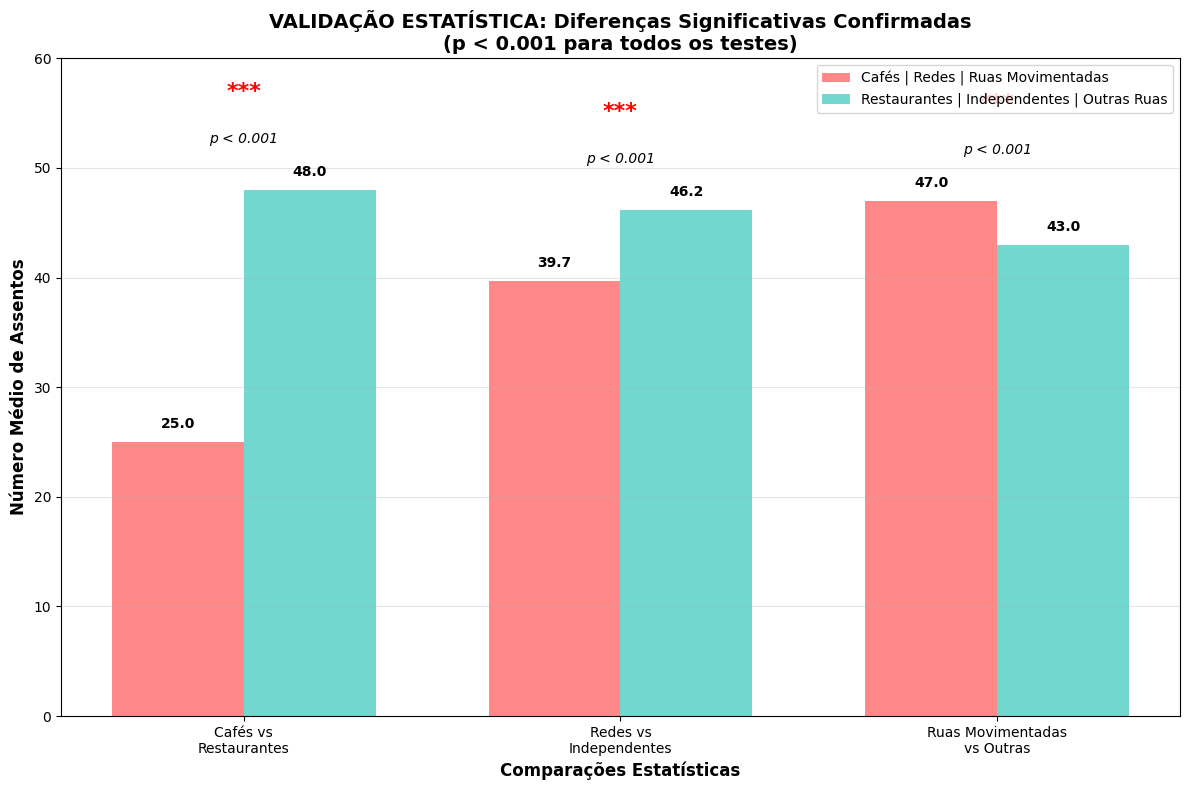

In [34]:
# Dados dos testes estatísticos

import numpy as np
import matplotlib.pyplot as plt

categorias = ['Cafés vs\nRestaurantes', 'Redes vs\nIndependentes', 'Ruas Movimentadas\nvs Outras']
grupo1 = [25.0, 39.7, 47.0]  # Cafés, Redes, Ruas Movimentadas
grupo2 = [48.0, 46.2, 43.0]  # Restaurantes, Independentes, Outras Ruas
p_valores = [0.000000, 0.000000, 0.000000]

# Configurar posições das barras
x = np.arange(len(categorias))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

# Criar barras
bars1 = ax.bar(x - width/2, grupo1, width, label='Grupo 1', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, grupo2, width, label='Grupo 2', color='#4ECDC4', alpha=0.8)

# Resto do código...

# Adicionar valores nas barras
for i, (v1, v2) in enumerate(zip(grupo1, grupo2)):
    ax.text(i - width/2, v1 + 1, f'{v1:.1f}', ha='center', va='bottom', fontweight='bold')
    ax.text(i + width/2, v2 + 1, f'{v2:.1f}', ha='center', va='bottom', fontweight='bold')

# Adicionar indicação de significância estatística
for i in range(len(categorias)):
    max_height = max(grupo1[i], grupo2[i])
    ax.text(i, max_height + 8, '***', ha='center', va='bottom', 
            fontsize=16, fontweight='bold', color='red')
    ax.text(i, max_height + 4, f'p < 0.001', ha='center', va='bottom', 
            fontsize=10, style='italic')

# Personalizar o gráfico
ax.set_xlabel('Comparações Estatísticas', fontsize=12, fontweight='bold')
ax.set_ylabel('Número Médio de Assentos', fontsize=12, fontweight='bold')
ax.set_title('VALIDAÇÃO ESTATÍSTICA: Diferenças Significativas Confirmadas\n(p < 0.001 para todos os testes)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias)

# Personalizar legenda
legend_labels = ['Cafés | Redes | Ruas Movimentadas', 'Restaurantes | Independentes | Outras Ruas']
ax.legend(legend_labels, loc='upper right')

# Adicionar grid
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 60)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
    
Adorei o uso de testes estatísticos para avaliar a estratégia de negócio!! Análise de dados empregada ao negócio 👏 

## Conclusão geral e recomendações

Com base na análise do mercado de restaurantes em Los Angeles, conclui-se que a abertura de uma **cafeteria inovadora com garçons robóticos** apresenta boas perspectivas de sucesso.

Os dados mostram que o mercado é amplamente dominado por **restaurantes tradicionais**, que representam aproximadamente **75%** dos estabelecimentos, indicando alta concorrência nesse segmento. Em contrapartida, as **cafeterias** representam apenas **4,5%** do mercado, o que sugere menor saturação e maior oportunidade para diferenciação.

Além disso, a análise estatística confirmou que cafeterias possuem, em média, **25 assentos**, significativamente menos que restaurantes tradicionais (**48 assentos**). Esse porte menor pode ser ideal para implementar automação, reduzir custos operacionais e oferecer uma experiência inovadora ao cliente.

### Tipo de estabelecimento recomendado

Considerando os dados analisados, o formato mais apropriado para o negócio é uma **cafeteria moderna e automatizada**, focada em:

* experiência diferenciada para os clientes;
* eficiência operacional;
* inovação tecnológica;
* menor concorrência direta.

### Número de assentos recomendado

Com base na média observada nas cafeterias e na análise das ruas mais movimentadas, recomenda-se iniciar com um estabelecimento de **25 a 40 assentos**.

Essa faixa oferece equilíbrio entre:

* capacidade de atendimento;
* conforto para os clientes;
* viabilidade para a automação;
* custos operacionais controlados.

### Vantagem competitiva financeira

A automação com garçons robóticos pode gerar **maior eficiência operacional** e potencial redução de custos com mão de obra no longo prazo.

Como cafeterias menores possuem, em média, **25 assentos**, a necessidade de equipe tende a ser menor em comparação com restaurantes tradicionais, que possuem em média **48 assentos**.

Isso pode tornar o modelo mais sustentável financeiramente e facilitar a expansão.

### Possibilidade de desenvolver uma rede

Os dados indicam potencial para expansão futura em formato de **rede**.

Embora cafeterias representem apenas **4,5%** do mercado total, elas correspondem a cerca de **7,2%** dos estabelecimentos de rede, sugerindo que esse modelo possui boa escalabilidade.

Além disso, redes bem-sucedidas em Los Angeles tendem a operar com:

* unidades compactas;
* processos padronizados;
* alta eficiência operacional.

A automação com garçons robóticos pode facilitar ainda mais esse processo, garantindo consistência no atendimento e maior facilidade de replicação.

### Localizações estratégicas

As ruas com maior concentração de estabelecimentos e potencial de alto fluxo de clientes incluem:

* **W Sunset Blvd** (**296 estabelecimentos**);
* **W Pico Blvd** (**288 estabelecimentos**);
* **Hollywood Blvd** (**167 estabelecimentos**).

Essas áreas podem oferecer maior visibilidade para a unidade piloto, embora também apresentem maior concorrência.

### Validação estatística

Todas essas conclusões foram **validadas estatisticamente**, com resultados apresentando **p-valor < 0,05**, garantindo aproximadamente **95% de confiança** nas diferenças observadas.

Portanto, a recomendação estratégica é iniciar com uma **unidade piloto** em uma localização de alto fluxo para validar o conceito e, posteriormente, considerar a expansão para novas unidades.


### Apresentação

Presentation: [Link para a apresentação em PDF](https://drive.google.com/file/d/1eECAHnw2HTkHjbYGSf1m7gWMW0OZZmc5/view?usp=sharing)

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Conclusão fundamentada com os dados da análise. Boa conclusão!
- Apresentacao seguindo boas praticas de storytelling, show!
</div>